## IMPORTING LIBS

In [19]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import json
import os

## load the data

In [20]:
DATA_PATH = "data/transit_ridership.csv"
OUTPUT_DIR = "output"

def load_data(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded {len(df)} records")
    return df

## CLEAN THE DATA

In [21]:
def clean_data(df):
    df = df.copy()

    df.columns = df.columns.str.strip().str.lower()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"])
    df = df.drop_duplicates()

    
    df["vehicle_type"] = df["vehicle_type"].str.strip().str.title()
    df["weather"] = df["weather"].str.strip().str.title()
    df["direction"] = df["direction"].str.strip().str.lower()
    df["route"] = df["route_id"].str.strip().str.upper()
    
    df["vehicle_type"] = df["vehicle_type"].replace({
        "Articulated bus": "Articulated Bus",
        "Standard bus": "Standard Bus",
        "Mini bus": "Minibus",
        "Minibus": "Minibus"
    })

    df["weather"] = df["weather"].replace({
        "Rainy": "Rain",
        "Cloudy": "Overcast"
    })
    
    df["boarding_count"] = pd.to_numeric(df["boarding_count"], errors="coerce")
    df["alighting_count"] = pd.to_numeric(df["alighting_count"], errors="coerce")

    df["boarding_count"] = df["boarding_count"].fillna(df["boarding_count"].median())
    df["alighting_count"] = df["alighting_count"].fillna(df["alighting_count"].median())

    df = df[df["boarding_count"] >= 0]
    df = df[df["alighting_count"] >= 0]
    df = df[df["trip_duration_min"] > 0]

    print(f"Cleaned data: {len(df)} records")
    return df

In [22]:
def add_features(df):
    
    df = df.copy()

    df["total_passengers"] = df["boarding_count"] + df["alighting_count"]
    df["month"] = df["date"].dt.to_period("M").astype(str)
    monthly = df.groupby("month")["boarding_count"].sum()

    return df

## Generate Summary

In [23]:
def generate_summary(df):

    if df.empty:
        return {
            "total_trips": 0,
            "date_range": None,
            "busiest_route": None,
            "avg_daily_ridership": 0,
            "ridership_by_vehicle_type": {},
            "ridership_by_weather": {},
            "top_5_routes_by_boarding": []
        }

    total_trips = len(df)

    start = df["date"].min().date()
    end = df["date"].max().date()
    date_range = f"{start.isoformat()} to {end.isoformat()}"

    
    route_totals = df.groupby("route")["boarding_count"].sum()
    busiest_route = route_totals.idxmax()

    daily = df.groupby("date")["boarding_count"].sum()
    avg_daily_ridership = float(round(daily.mean(), 1))

    vehicle = df.groupby("vehicle_type")["boarding_count"].sum()
    ridership_by_vehicle_type = dict(sorted(
        ((k, int(v)) for k, v in vehicle.items())
    ))

    weather = df.groupby("weather")["boarding_count"].sum()
    ridership_by_weather = dict(sorted(
        ((k, int(v)) for k, v in weather.items())
    ))

    top_routes = route_totals.sort_values(ascending=False).head(5)
    top_5_routes = [
        {"route": r, "total_boardings": int(v)}
        for r, v in top_routes.items()
    ]

    return {
        "total_trips": int(total_trips),
        "date_range": date_range,
        "busiest_route": busiest_route,
        "avg_daily_ridership": avg_daily_ridership,
        "ridership_by_vehicle_type": ridership_by_vehicle_type,
        "ridership_by_weather": ridership_by_weather,
        "top_5_routes_by_boarding": top_5_routes
    }

## creating the JSON summary

In [24]:
def save_summary(summary, output_dir=OUTPUT_DIR):
    os.makedirs(output_dir, exist_ok=True)
    with open(f"{output_dir}/summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    print("Summary saved.")
    

## visualizations

In [25]:
def create_visualizations(df, output_dir="output"):

    df = df.copy()
    os.makedirs(output_dir, exist_ok=True)

    df["total_passengers"] = df["boarding_count"] + df["alighting_count"]
   
    
    monthly = df.groupby(df["date"].dt.month)["boarding_count"].sum()
    fig, ( (ax0,ax1) , (ax2,ax3) )=  plt.subplots(2,2,figsize=(20,20))
    ax0.plot(monthly.index, monthly.values, marker='o')
    
    ax0.set(title="Monthly Ridership(Total Boardings)", xlabel="Month" , ylabel="Total Boarding")
    ax0.tick_params(axis= "x", rotation=45)

    route_boarding = df.groupby("route_id")["boarding_count"].sum()
    ax1.barh(route_boarding.index, route_boarding.values)
    ax0.set(title="Total Boarding by Route", xlabel="Total Boarding" , ylabel="Route")

    vehicle_avg = df.groupby("vehicle_type")["trip_duration_min"].mean()
    ax2.bar(vehicle_avg.index, vehicle_avg.values)
    ax2.set(title="Average Trip Duration by Vehicle Type" ,xlabel="Vehicle Type", ylabel="Average Trip Duration (min)")
    
    df["weather"] = df["weather"].str.strip().str.title()
    weather_avg = df.groupby("weather")["boarding_count"].mean()
    colors = ["orange", "blue", "red", "purple"]

    ax3.bar(weather_avg.index, weather_avg.values, color=colors)
    ax3.set_title("Average Boardings by Weather Condition")
    ax3.set_xlabel("Weather Condition")
    ax3.set_ylabel("Average Boardings per Trip")
    
    fig.savefig(f"{output_dir}/all_visualizations.png", dpi=150, bbox_inches="tight")

Loaded 1993 records
Cleaned data: 1648 records
{'total_trips': 1648, 'date_range': '2024-01-01 to 2024-12-31', 'busiest_route': 'R208', 'avg_daily_ridership': 1858.9, 'ridership_by_vehicle_type': {'Articulated': 2816, 'Articulated Bus': 213117, 'Mini Bus': 3365, 'Minibus': 231361, 'Standard Bus': 220071, 'Std Bus': 4045}, 'ridership_by_weather': {'Clear': 164281, 'Overcast': 180435, 'Rain': 177749, 'Snow': 152310}, 'top_5_routes_by_boarding': [{'route': 'R208', 'total_boardings': 68942}, {'route': 'R105', 'total_boardings': 66123}, {'route': 'R302', 'total_boardings': 63771}, {'route': 'R206', 'total_boardings': 63741}, {'route': 'R205', 'total_boardings': 63069}]}
Summary saved.
Pipeline complete.


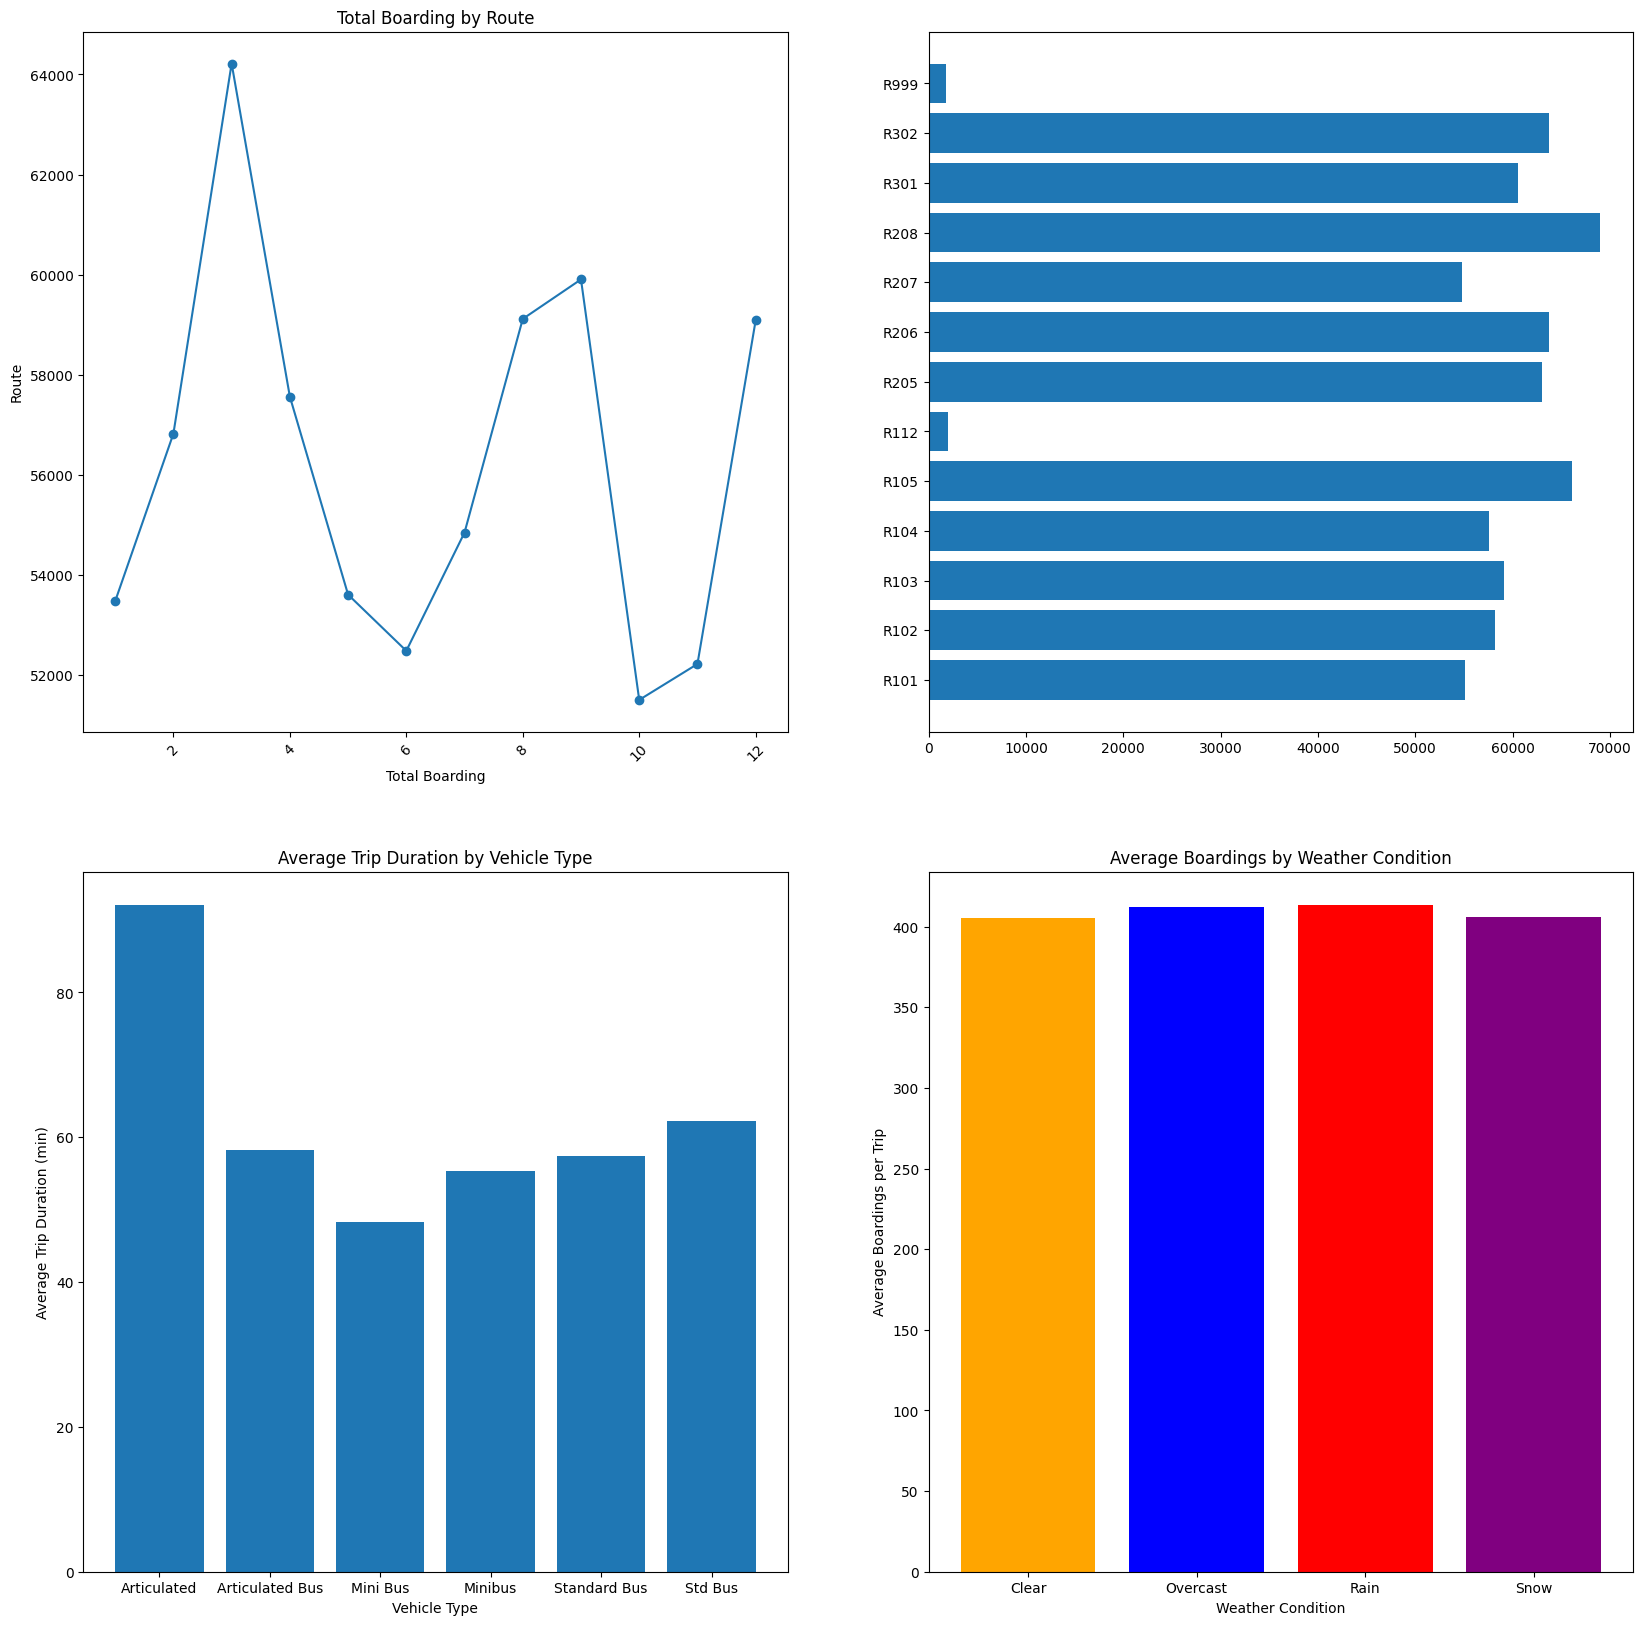

In [26]:
def main():
    df = load_data(DATA_PATH)
    df = clean_data(df)
    df = add_features(df)

    summary = generate_summary(df)
    print(summary)

    save_summary(summary)
    create_visualizations(df)

    print("Pipeline complete.")


if __name__ == "__main__":
        main()